Dataset Shape: (1766, 15)


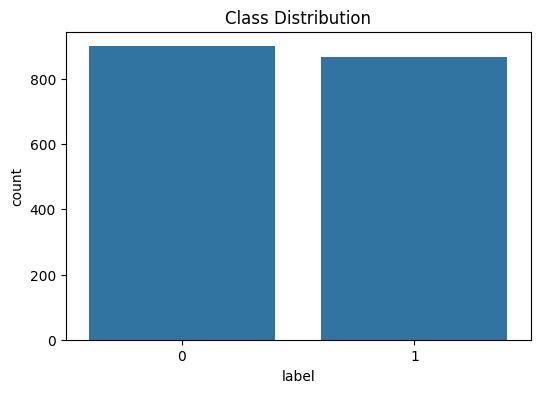

Missing values:
 EAR_left              0
EAR_right             0
EAR_avg               0
left_eye_width        0
left_eye_height       0
right_eye_width       0
right_eye_height      0
left_openness         0
right_openness        0
left_eyelid_dist      0
right_eyelid_dist     0
pupil_visibility      0
left_eyebrow_dist     0
right_eyebrow_dist    0
label                 0
dtype: int64

Sample data:


,EAR_left,EAR_right,EAR_avg,left_eye_width,left_eye_height,right_eye_width,right_eye_height,left_openness,right_openness,left_eyelid_dist,right_eyelid_dist,pupil_visibility,left_eyebrow_dist,right_eyebrow_dist,label
0,0.217675,0.265847,0.241761,78.638413,17.117643,68.007353,18.079567,0.217675,0.265847,17.117643,18.079567,17.598605,51.478151,56.850682,0
1,0.232954,0.272677,0.252816,78.057671,18.183825,73.109507,19.935316,0.232954,0.272677,18.183825,19.935316,19.059570,48.373546,56.850682,0
2,0.243319,0.308078,0.275698,79.056942,19.236018,72.339477,22.286193,0.243319,0.308078,19.236018,22.286193,20.761105,48.507731,55.000000,0
3,0.221117,0.282521,0.251819,77.414469,17.117643,70.064256,19.794597,0.221117,0.282521,17.117643,19.794597,18.456120,50.487622,54.671748,0
4,0.252425,0.293368,0.272897,78.160092,19.729566,73.246160,21.488104,0.252425,0.293368,19.729566,21.488104,20.608835,46.389654,54.671748,0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import joblib
import time

df = pd.read_csv('features.csv')
print("Dataset Shape:", df.shape)
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title("Class Distribution")
plt.show()
print("Missing values:\n", df.isnull().sum())
df = df.dropna()

print("\nSample data:")
display(df.head())

In [ ]:
X = df.drop('label', axis=1)
y = df['label']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_scaled, y)

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, stratify=y_res, random_state=42)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (1440, 14)
Testing set shape: (360, 14)


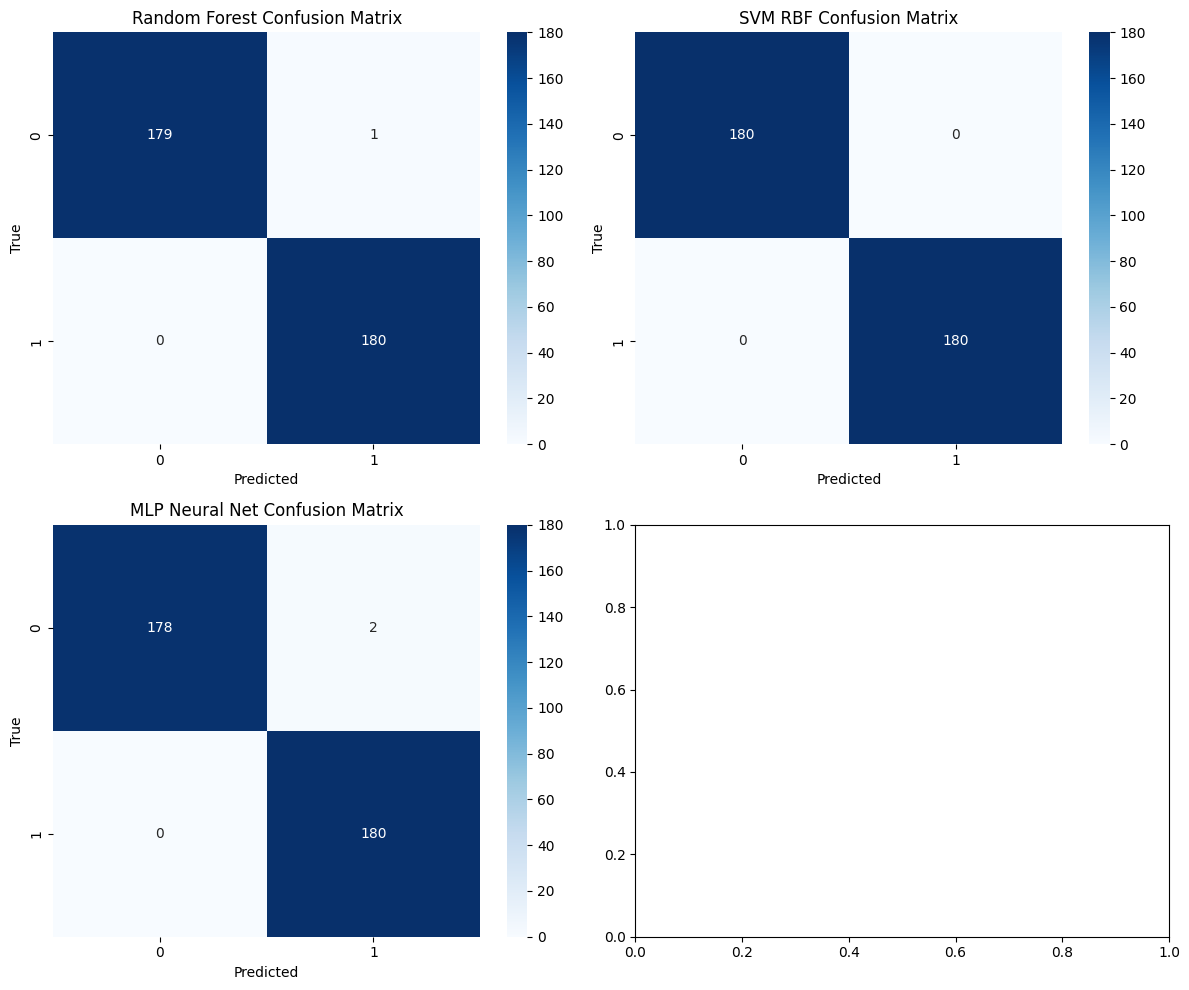

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM RBF': SVC(kernel='rbf', probability=True, random_state=42),
    'MLP Neural Net': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

results = []
trained_models = {}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, (name, model) in enumerate(models.items()):
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_pred = model.predict(X_test)
    
    # Metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    results.append({
        'Model': name,
        'Train Acc': train_acc,
        'Test Acc': test_acc,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Train Time (s)': train_time
    })
    trained_models[name] = model
    
    # Confusion matrix subplot
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f"{name} Confusion Matrix")
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')

plt.tight_layout()
plt.show()

,Model,Train Acc,Test Acc,Precision,Recall,F1-Score,Train Time (s)
0,Random Forest,1.000000,0.997222,0.997238,0.997222,0.997222,0.156262
1,SVM RBF,0.995139,1.000000,1.000000,1.000000,1.000000,0.008337
2,MLP Neural Net,0.995139,0.994444,0.994505,0.994444,0.994444,0.106333


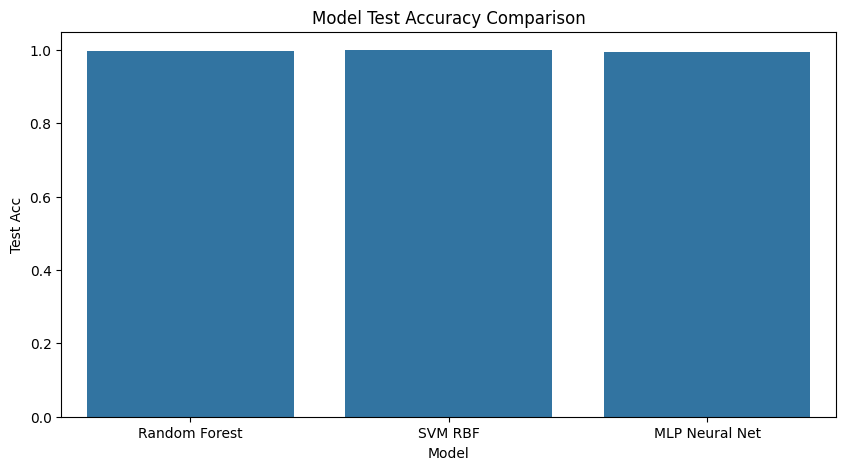

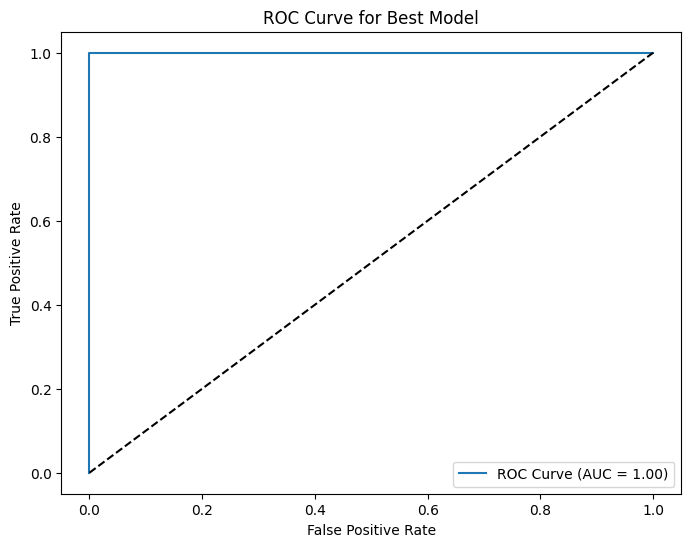

Best Model Winners is: SVM RBF
Saved blink_model.pkl and scaler.pkl


In [11]:
# Comparison Table
results_df = pd.DataFrame(results)
display(results_df)

# Accuracy Bar Chart
plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='Test Acc', data=results_df)
plt.title("Model Test Accuracy Comparison")
plt.ylim(0, 1.05)
plt.show()

# Best Model Save
best_model_name = results_df.loc[results_df['Test Acc'].idxmax(), 'Model']
best_model = trained_models[best_model_name]

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# ROC Curve
if hasattr(best_model, 'predict_proba'):
    # For binary classification, we can just use y_test directly
    y_score = best_model.predict_proba(X_test)
    plt.figure(figsize=(8,6))
    fpr, tpr, _ = roc_curve(y_test, y_score[:, 1])
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc(fpr, tpr):.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for Best Model')
    plt.legend(loc="lower right")
    plt.show()

print(f"Best Model Winners is: {best_model_name}")
joblib.dump(best_model, 'blink_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Saved blink_model.pkl and scaler.pkl")

# Feature Importance (if applicable)
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    indices = np.argsort(importances)
    plt.figure(figsize=(10,6))
    plt.title('Feature Importances')
    plt.barh(range(len(indices)), importances[indices], align='center')
    plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
    plt.xlabel('Relative Importance')
    plt.show()
